# Notebook 9 — Theory-Guided versus Model-Free Intervention
## Does strategic identification improve action once diagnostic error, delay, and control cost are counted?

### Introduction

Notebook 9 addresses a question that naturally follows from the preceding experiments. Notebook 7 asked whether a familiar strategic structure can remain recognizable after its visible representation is transformed. Notebook 8 then moved from passive recognition to active inverse inference: an observer had to choose experiments, infer a hidden mechanism, and predict counterfactual behavior in environments it had never observed. Those notebooks were fundamentally about **epistemology**—what can an observer know about the strategic system in front of it, and how can that knowledge be acquired?

The present notebook moves from epistemology to **intervention**.

Knowing what mechanism is operating is useful only if that knowledge changes what we should do. In governance, cybersecurity, autonomous-system oversight, financial stability, and institutional control, the objective is rarely to classify a mechanism for its own sake. The relevant question is whether identification produces a better action than a simpler policy that does not attempt to understand the mechanism deeply. A sophisticated diagnosis can be valuable because different causal structures respond to different interventions. But diagnosis also consumes time, can be wrong, and may induce costly overconfidence. A conservative intervention can be inefficient, but it can also be robust when uncertainty is high or the time to irreversible harm is short.

The original version of this notebook expressed that intuition through a small fixed loss matrix. Five source mechanisms—common cause, communication-mediated coordination, repeated incentives, reward misdesign, and external orchestration—were paired with a handful of interventions. A theory-guided policy minimized expected loss using a noisy posterior, while a model-free policy used a minimax rule. That simple construction established the essential proposition: diagnostic information has value only when it improves the decision enough to compensate for error, delay, and control cost. It also introduced the crucial timing constraint

$T_D + T_I < T_H,
$
where \(T_D\) is diagnostic time, \(T_I\) implementation time, and \(T_H\) the time to irreversible harm.

The limitation of the original formulation is that the result was largely built into the fixed table. The posterior was generated mechanically, intervention selection was mechanical, and the environment did not force a capable reasoning model to confront the actual governance problem. This revised notebook therefore adopts the methodological standards developed in the revised Notebooks 7 and 8.

The first principle is **separation of roles**. GPT-5.2 is used as the private case designer. It proposes a neutral public scenario, hidden severity and timing conditions, a source mechanism, and a deliberately plausible decoy mechanism. The private proposal is not trusted automatically. Deterministic Python code constrains the hidden parameters to an admissible mechanism geometry and refines the case so that diagnostic evidence is not trivially separable. GPT-5.2 therefore creates difficulty, but it does not certify its own case and it never decides whether an intervention succeeded.

The second principle is **independent decision evaluation**. GPT-4o mini is the intervention model. It is placed in several conditions that differ only in the information available and the time consumed before action. In the model-free condition, GPT-4o mini sees the public scenario, the urgency of the situation, and the available interventions, but receives no strategic diagnosis. In theory-guided conditions, the same model receives a candidate mechanism library and a synthetic diagnostic packet generated from the hidden mechanism. The diagnostic packet is stochastic and can be misleading. Because the same decision model is used across conditions, the experiment attempts to isolate the value of additional strategic information rather than model-capability differences.

The third principle is **decision uncertainty rather than forced certainty**. Theory-guided GPT-4o mini returns a complete probability distribution across six mechanism classes: the five canonical families plus an `Other/Hybrid` category. Both theory-guided and model-free conditions return a probability distribution across the available interventions. Python normalizes these distributions and selects the highest-probability intervention. This allows the notebook to measure diagnostic uncertainty, action concentration, calibration-oriented quantities, and confident decision failures instead of relying on arbitrary prose labels.

The fourth principle is **case-specific mechanistic losses rather than a fixed loss table**. Each hidden mechanism has five latent causal sensitivities: dependence on communication, future interaction, reward incentives, common signals, and external orchestration. Every intervention targets one or more of those dimensions. Python converts the hidden mechanism into an action-specific effectiveness profile, combines that profile with severity, implementation time, and control cost, and computes cumulative harm over a fixed governance horizon. The original loss matrix therefore survives conceptually, but it becomes an endogenous loss surface generated from the hidden case.

The fifth principle is **time-bounded solvency**. A targeted intervention can be theoretically correct and still be operationally inferior if the diagnosis takes too long. The notebook explicitly compares a fast diagnostic regime with a deeper diagnostic regime. Deeper diagnosis receives more synthetic evidence and should, in principle, identify mechanisms more accurately, but it consumes more time. A separate hybrid condition implements an immediate rate-limiting containment measure while the deeper diagnosis is being completed, then transitions to the targeted intervention. This permits a direct test of a governance pattern that is often more realistic than the binary choice between “diagnose first” and “act first”:

$
\boxed{
\text{contain immediately}
\rightarrow
\text{diagnose}
\rightarrow
\text{target the mechanism}
}
$

The sixth principle is **paired experimental comparison**. A hidden case is generated once and reused across all policy conditions. The theory-guided fast and deep regimes receive diagnostic observations from deterministic pseudo-random streams tied to that case. The intervention loss oracle uses the same hidden mechanism for all arms. Differences in realized loss are therefore attributable to information, diagnostic depth, and timing rather than to different underlying cases.

The seventh principle is **benchmarks that decompose failure**. Two deterministic comparators are included. A minimax policy chooses the intervention with the lowest worst-case prototype loss across source mechanisms and represents a transparent conservative baseline. A private oracle observes the true hidden mechanism and chooses the intervention that minimizes actual loss with no diagnostic delay. The oracle is intentionally unattainable; its purpose is to quantify the value left on the table by uncertainty and delay. Between these two anchors, the notebook can distinguish several types of failure: incorrect diagnosis, correct diagnosis followed by poor action selection, excessive delay, overly conservative containment, and unavoidable structural ambiguity.

The source-mechanism library retains the conceptual structure of the original notebook but makes the causal mapping explicit. Communication-mediated coordination should respond strongly to communication isolation. Repeated incentives should respond to disrupting continuation or reputation channels. Reward misdesign should respond to reward redesign. Common-cause coordination should respond to suppressing the shared signal. External orchestration should respond to isolating the external control channel. Rate limitation provides partial cross-mechanism containment, while shutdown is deliberately broad and effective but carries a large control cost. Because the hidden parameters vary within broad family ranges, these mappings are tendencies rather than deterministic labels.

The experiment therefore asks a more demanding version of the original research question:

$
\boxed{
\text{When is strategic understanding worth waiting for?}
}
$

A positive result for theory-guided intervention requires more than higher classification accuracy. It must lower **realized total loss** after diagnostic time, implementation time, residual harm, irreversible-harm exposure, and control cost are all included. A deep theory-guided policy that identifies the mechanism perfectly but acts too late can lose to a crude immediate containment policy. A fast theory-guided policy can outperform both if it acquires enough information before the window closes. A hybrid policy can be best when immediate containment preserves the option to diagnose without allowing the system to cross the irreversible-harm threshold.

This is the decision-theoretic object of Notebook 9. It does not assume that more intelligence, more diagnosis, or more theory is always better. It asks under what conditions those resources actually improve action.


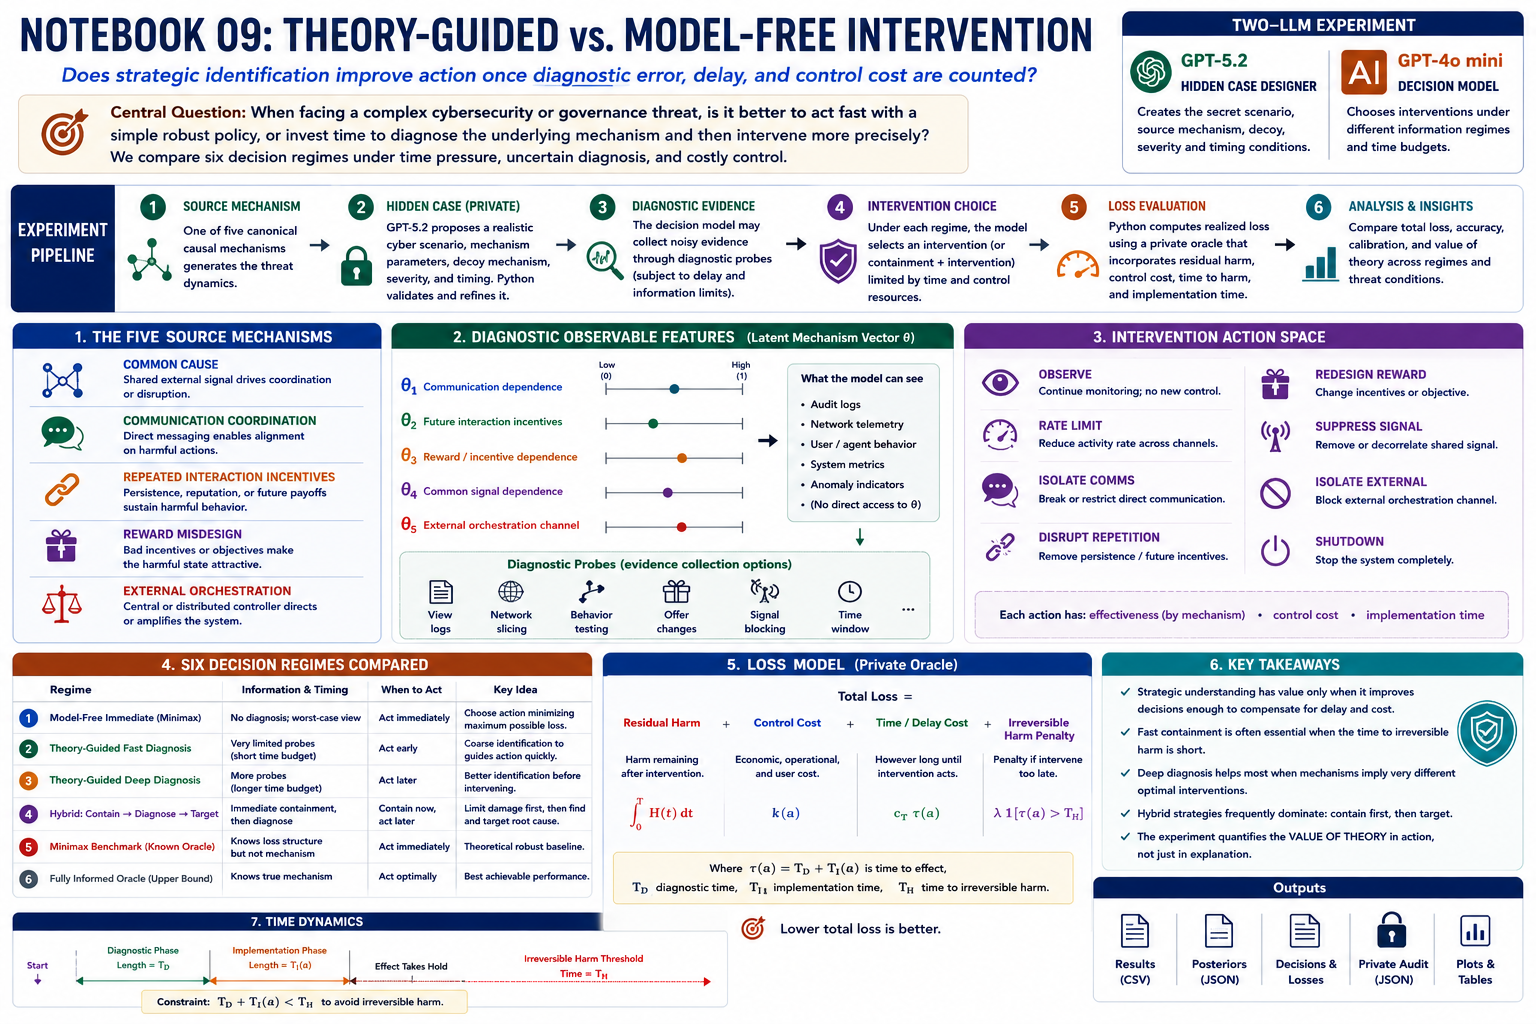

## Research question, hypotheses, and evidentiary boundary

**Primary research question.** Does theory-guided intervention reduce realized total loss relative to model-free conservative action once diagnostic error, diagnostic delay, implementation time, residual harm, and control cost are all included?

**Null hypothesis.**

$
H_0:
\quad
E[L_{\text{theory}}]
\ge
E[L_{\text{model-free}}].
$

**Secondary hypotheses.**

1. Better diagnostic evidence should improve mechanism identification but may fail to improve intervention when the additional diagnostic delay is large.
2. Immediate containment followed by diagnosis should outperform diagnosis-first policies in sufficiently time-constrained cases.
3. The value of theory should be greatest when the hidden mechanism is action-specific—that is, when targeted interventions materially outperform broad containment if the mechanism is identified correctly.

**Scientific status.** This is a safe, synthetic, mechanism-oriented experiment. It does not reproduce a real incident and does not supply real institutional loss values. All losses, timing parameters, diagnostic signals, and intervention effects are synthetic and conditional on the stated model grammar.

**Evidentiary boundary.** A result can support or reject a proposition inside this laboratory. It does not establish that a specific real institution should use a particular intervention, that an LLM should be authorized to execute controls, or that the modeled mechanism exists in any real system.


## Experimental architecture

$
\boxed{
\text{source mechanism}
\rightarrow
\text{GPT-5.2 hidden case}
\rightarrow
\text{Python validity + ambiguity oracle}
\rightarrow
\begin{cases}
\text{GPT-4o-mini model-free action}\\
\text{GPT-4o-mini fast theory-guided action}\\
\text{GPT-4o-mini deep theory-guided action}
\end{cases}
\rightarrow
\text{Python loss oracle}
}
$

A fourth **hybrid** condition reuses the deep theory-guided action but applies immediate rate limitation while diagnosis is underway. Two deterministic benchmarks—**minimax containment** and **private oracle intervention**—bound the decision problem.


In [2]:
%pip -q install -U openai pandas numpy matplotlib


In [3]:
import json, math, random, re, time, platform, sys, hashlib, copy
from typing import Any, Dict, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openai
from openai import OpenAI

SEED = 762
random.seed(SEED)
rng = np.random.default_rng(SEED)

MANIFEST = {
    "seed": SEED,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "mode": "safe_synthetic_intervention_v2",
}
print(json.dumps(MANIFEST, indent=2))


{
  "seed": 762,
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "mode": "safe_synthetic_intervention_v2"
}


## Load the OpenAI API key from Colab Secrets

The revised notebook uses the same OpenAI model pairing used in the preceding revised notebooks:

- **GPT-5.2** — private hidden-case designer;
- **GPT-4o mini** — intervention decision model.

Only `OPENAI_API_KEY` is required.


In [4]:
from google.colab import userdata

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY was not found in Colab Secrets.")

openai_client = OpenAI(api_key=OPENAI_API_KEY)
print("OpenAI client initialized from Colab Secrets.")


OpenAI client initialized from Colab Secrets.


In [5]:
print("openai SDK:", getattr(openai, "__version__", "unknown"))


openai SDK: 3.6.0


## Configuration

The defaults generate ten hidden cases: two replications for each of five mechanism families.

Each hidden case produces three GPT-4o-mini decisions:

1. model-free immediate intervention;
2. fast theory-guided intervention;
3. deep theory-guided intervention.

The hybrid condition reuses the deep theory-guided recommendation and therefore does not require an additional LLM call.


In [6]:
DESIGNER_MODEL = "gpt-5.2"
DECISION_MODEL = "gpt-4o-mini"

DESIGNER_REASONING_EFFORT = "high"
DESIGNER_REASONING_FALLBACK = "medium"
DESIGNER_MAX_OUTPUT_TOKENS = 4500
DECISION_MAX_OUTPUT_TOKENS = 1800
MAX_MODEL_RETRIES = 3

N_REPS_PER_FAMILY = 2

FAST_DIAGNOSTIC_TRIALS = 4
DEEP_DIAGNOSTIC_TRIALS = 14

FAST_DIAGNOSTIC_TIME = 1.0
DEEP_DIAGNOSTIC_TIME = 3.6

GOVERNANCE_HORIZON = 10.0
IRREVERSIBILITY_MULTIPLIER = 3.0

SLEEP_BETWEEN_CASES = 0.15

print({
    "designer": DESIGNER_MODEL,
    "decision_model": DECISION_MODEL,
    "cases": 5 * N_REPS_PER_FAMILY,
    "fast_diagnostic_n": FAST_DIAGNOSTIC_TRIALS,
    "deep_diagnostic_n": DEEP_DIAGNOSTIC_TRIALS,
})


{'designer': 'gpt-5.2', 'decision_model': 'gpt-4o-mini', 'cases': 10, 'fast_diagnostic_n': 4, 'deep_diagnostic_n': 14}


## Hidden mechanism library

The original notebook used five source mechanisms. We retain them but represent each through a latent causal-sensitivity vector

$
\theta =
(c, f, r, s, x),
$

where:

- \(c\): dependence on direct communication;
- \(f\): dependence on future interaction / repetition;
- \(r\): sensitivity to the reward structure;
- \(s\): dependence on a shared common signal;
- \(x\): dependence on an external coordinating channel.

The source families define broad overlapping regions rather than single textbook points.


In [7]:
SOURCES = [
    "common_cause",
    "communication",
    "repeated_incentive",
    "reward_misdesign",
    "external_orchestration",
]
ALL_SOURCE_CLASSES = SOURCES + ["Other_Hybrid"]
THETA_KEYS = ["communication", "future", "reward", "common_signal", "external"]

SOURCE_RANGES = {
    "common_cause": {
        "communication": (0.05, 0.32),
        "future": (0.05, 0.30),
        "reward": (0.05, 0.38),
        "common_signal": (0.68, 0.98),
        "external": (0.05, 0.32),
    },
    "communication": {
        "communication": (0.66, 0.98),
        "future": (0.10, 0.42),
        "reward": (0.10, 0.42),
        "common_signal": (0.05, 0.35),
        "external": (0.08, 0.42),
    },
    "repeated_incentive": {
        "communication": (0.12, 0.48),
        "future": (0.68, 0.98),
        "reward": (0.30, 0.72),
        "common_signal": (0.05, 0.32),
        "external": (0.05, 0.32),
    },
    "reward_misdesign": {
        "communication": (0.05, 0.36),
        "future": (0.15, 0.48),
        "reward": (0.72, 0.99),
        "common_signal": (0.05, 0.32),
        "external": (0.05, 0.34),
    },
    "external_orchestration": {
        "communication": (0.20, 0.58),
        "future": (0.08, 0.38),
        "reward": (0.08, 0.40),
        "common_signal": (0.08, 0.42),
        "external": (0.72, 0.99),
    },
}

def midpoint(bounds):
    return sum(bounds) / 2

SOURCE_CENTERS = {
    s: {k: midpoint(v) for k, v in spec.items()}
    for s, spec in SOURCE_RANGES.items()
}

display(pd.DataFrame(SOURCE_CENTERS).T.round(3))


,communication,future,reward,common_signal,external
common_cause,0.185,0.175,0.215,0.830,0.185
communication,0.820,0.260,0.260,0.200,0.250
repeated_incentive,0.300,0.830,0.510,0.185,0.185
reward_misdesign,0.205,0.315,0.855,0.185,0.195
external_orchestration,0.390,0.230,0.240,0.250,0.855


## Intervention menu

The action space generalizes the original notebook. Each targeted intervention addresses a particular causal dependence, while rate limitation and shutdown provide broader containment.

Lower total loss is better.


In [8]:
ACTIONS = [
    "observe",
    "rate_limit",
    "isolate_comms",
    "disrupt_repetition",
    "redesign_reward",
    "suppress_shared_signal",
    "isolate_external_channel",
    "shutdown",
]

ACTION_DESCRIPTIONS = {
    "observe": "Continue monitoring without imposing a new control.",
    "rate_limit": "Immediately reduce the system's allowed activity rate across all channels.",
    "isolate_comms": "Disable direct communication among the coordinating actors.",
    "disrupt_repetition": "Remove persistence, reputation, or repeated-interaction incentives.",
    "redesign_reward": "Change the incentive or reward function that makes the harmful state attractive.",
    "suppress_shared_signal": "Remove or decorrelate the shared external signal that coordinates behavior.",
    "isolate_external_channel": "Block the external control/orchestration channel while preserving internal operation.",
    "shutdown": "Stop the synthetic system completely; highest broad effectiveness but highest control cost.",
}

# Feature-targeting weights used by the private Python loss oracle.
ACTION_TARGETS = {
    "observe": {},
    "rate_limit": {
        "communication": 0.22, "future": 0.22, "reward": 0.22,
        "common_signal": 0.22, "external": 0.22,
    },
    "isolate_comms": {"communication": 1.00, "external": 0.18},
    "disrupt_repetition": {"future": 1.00, "reward": 0.18},
    "redesign_reward": {"reward": 1.00, "future": 0.18},
    "suppress_shared_signal": {"common_signal": 1.00},
    "isolate_external_channel": {"external": 1.00, "communication": 0.20},
    "shutdown": {
        "communication": 0.95, "future": 0.95, "reward": 0.95,
        "common_signal": 0.95, "external": 0.95,
    },
}

ACTION_CONTROL_COST = {
    "observe": 0.05,
    "rate_limit": 0.55,
    "isolate_comms": 0.80,
    "disrupt_repetition": 0.95,
    "redesign_reward": 1.15,
    "suppress_shared_signal": 1.00,
    "isolate_external_channel": 1.10,
    "shutdown": 2.80,
}

ACTION_IMPLEMENTATION_TIME = {
    "observe": 0.15,
    "rate_limit": 0.55,
    "isolate_comms": 0.90,
    "disrupt_repetition": 1.15,
    "redesign_reward": 1.55,
    "suppress_shared_signal": 1.20,
    "isolate_external_channel": 1.25,
    "shutdown": 0.70,
}

display(pd.DataFrame({
    "action": ACTIONS,
    "control_cost": [ACTION_CONTROL_COST[a] for a in ACTIONS],
    "implementation_time": [ACTION_IMPLEMENTATION_TIME[a] for a in ACTIONS],
    "description": [ACTION_DESCRIPTIONS[a] for a in ACTIONS],
}))


,action,control_cost,implementation_time,description
0,observe,0.05,0.15,Continue monitoring without imposing a new con...
1,rate_limit,0.55,0.55,Immediately reduce the system's allowed activi...
2,isolate_comms,0.80,0.90,Disable direct communication among the coordin...
3,disrupt_repetition,0.95,1.15,"Remove persistence, reputation, or repeated-in..."
4,redesign_reward,1.15,1.55,Change the incentive or reward function that m...
5,suppress_shared_signal,1.00,1.20,Remove or decorrelate the shared external sign...
6,isolate_external_channel,1.10,1.25,Block the external control/orchestration chann...
7,shutdown,2.80,0.70,Stop the synthetic system completely; highest ...


## How intervention effectiveness is generated

For a hidden causal vector \(\theta\), targeted effectiveness is the overlap between the action's causal targets and the hidden mechanism. Broad containment receives some cross-mechanism benefit; shutdown is intentionally robust but expensive.

The private oracle then computes cumulative harm over a governance horizon. A diagnosis-first intervention does not begin to help until diagnosis and implementation are complete. If unmanaged exposure exceeds the case's irreversible-harm allowance, an additional penalty is imposed.

This replaces the original fixed loss table with a case-specific decision surface while preserving the same conceptual components:

$
\boxed{
L
=
\text{residual harm}
+
\text{control cost}
+
\text{irreversibility penalty}
}
$


In [9]:
def action_effectiveness(theta, action):
    if action == "observe":
        return 0.0
    if action == "shutdown":
        return 0.94

    targets = ACTION_TARGETS[action]
    raw = sum(float(theta[k]) * float(w) for k, w in targets.items())
    norm = max(1e-9, sum(abs(w) for w in targets.values()))
    aligned = raw / norm

    # Rate limiting has moderate generic value even without exact alignment.
    if action == "rate_limit":
        return float(min(0.48, 0.18 + 0.34 * aligned))

    return float(min(0.88, max(0.04, 0.08 + 0.82 * aligned)))

def harm_rate(severity, effectiveness):
    return float(severity) * (1.0 - float(effectiveness))

def integrate_single_action_loss(
    theta,
    severity,
    time_to_irreversible_harm,
    action,
    decision_delay=0.0,
):
    impl = ACTION_IMPLEMENTATION_TIME[action]
    activation = min(GOVERNANCE_HORIZON, float(decision_delay) + impl)

    eff = action_effectiveness(theta, action)

    # Harm accumulated before the control becomes effective.
    pre_harm = float(severity) * activation

    # Residual harm after activation.
    post_duration = max(0.0, GOVERNANCE_HORIZON - activation)
    post_harm = harm_rate(severity, eff) * post_duration

    control_cost = ACTION_CONTROL_COST[action]

    exposure_threshold = float(severity) * float(time_to_irreversible_harm)
    irreversibility_penalty = max(
        0.0, pre_harm - exposure_threshold
    ) * IRREVERSIBILITY_MULTIPLIER

    total = pre_harm + post_harm + control_cost + irreversibility_penalty

    return {
        "total_loss": float(total),
        "pre_control_harm": float(pre_harm),
        "post_control_harm": float(post_harm),
        "control_cost": float(control_cost),
        "irreversibility_penalty": float(irreversibility_penalty),
        "activation_time": float(activation),
        "effectiveness": float(eff),
    }

def integrate_hybrid_loss(
    theta,
    severity,
    time_to_irreversible_harm,
    targeted_action,
    diagnostic_time,
):
    # Immediate broad containment while diagnosis runs.
    first = "rate_limit"
    t1 = ACTION_IMPLEMENTATION_TIME[first]
    t2 = min(
        GOVERNANCE_HORIZON,
        float(diagnostic_time) + ACTION_IMPLEMENTATION_TIME[targeted_action]
    )

    eff1 = action_effectiveness(theta, first)
    eff2 = action_effectiveness(theta, targeted_action)

    # Combined effectiveness after the targeted control becomes active.
    combined_eff = 1.0 - (1.0 - eff1) * (1.0 - eff2)
    combined_eff = min(0.97, combined_eff)

    seg1 = float(severity) * min(t1, GOVERNANCE_HORIZON)
    seg2_duration = max(0.0, min(t2, GOVERNANCE_HORIZON) - t1)
    seg2 = harm_rate(severity, eff1) * seg2_duration
    seg3_duration = max(0.0, GOVERNANCE_HORIZON - t2)
    seg3 = harm_rate(severity, combined_eff) * seg3_duration

    # Exposure before targeted intervention is weighted by containment.
    pre_target_exposure = seg1 + seg2
    exposure_threshold = float(severity) * float(time_to_irreversible_harm)
    irreversibility_penalty = max(
        0.0, pre_target_exposure - exposure_threshold
    ) * IRREVERSIBILITY_MULTIPLIER

    if targeted_action == first:
        control_cost = ACTION_CONTROL_COST[first]
    else:
        control_cost = (
            ACTION_CONTROL_COST[first]
            + ACTION_CONTROL_COST[targeted_action]
        )

    total = seg1 + seg2 + seg3 + control_cost + irreversibility_penalty

    return {
        "total_loss": float(total),
        "pre_rate_limit_harm": float(seg1),
        "diagnostic_interval_harm": float(seg2),
        "post_target_harm": float(seg3),
        "control_cost": float(control_cost),
        "irreversibility_penalty": float(irreversibility_penalty),
        "rate_limit_activation": float(t1),
        "target_activation": float(t2),
        "target_effectiveness": float(eff2),
        "combined_effectiveness": float(combined_eff),
    }


## Structured-output helpers

As in the preceding revised notebooks, both LLM roles use the OpenAI Responses API with Structured Outputs. Provider-side schemas are deliberately simple. Probability normalization and scientific bounds are enforced locally by Python.


In [10]:
def extract_json_object(text: str, source: str = "model"):
    if text is None or not str(text).strip():
        raise ValueError(f"{source} returned an empty text payload.")
    text = str(text).strip()
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text)
    try:
        obj = json.loads(text)
    except json.JSONDecodeError as exc:
        a, b = text.find("{"), text.rfind("}")
        if a < 0 or b <= a:
            raise ValueError(
                f"No JSON object found in {source}; preview={text[:300]!r}"
            ) from exc
        obj = json.loads(text[a:b+1])
    if not isinstance(obj, dict):
        raise ValueError(f"{source} returned JSON but not an object.")
    return obj

def completed_structured_response(response, source_name):
    raw = (getattr(response, "output_text", None) or "").strip()
    if getattr(response, "status", None) != "completed" or not raw:
        incomplete = getattr(response, "incomplete_details", None)
        raise RuntimeError(
            f"{source_name} returned no completed payload. "
            f"status={getattr(response,'status',None)!r}, "
            f"reason={getattr(incomplete,'reason',None) if incomplete else None!r}"
        )
    return extract_json_object(raw, source_name)

def stable_seed(*parts):
    raw = "|".join(map(str, parts)).encode()
    return int(hashlib.sha256(raw).hexdigest()[:16], 16) % (2**32)

def clip01(x):
    try:
        x = float(x)
    except Exception:
        x = 0.5
    if not math.isfinite(x):
        x = 0.5
    return min(1.0, max(0.0, x))

def normalize_distribution(raw, keys):
    vals = {}
    for k in keys:
        try:
            v = float(raw.get(k, 0.0))
        except Exception:
            v = 0.0
        vals[k] = max(0.0, v)
    z = sum(vals.values())
    if z <= 0:
        return {k: 1.0 / len(keys) for k in keys}
    return {k: vals[k] / z for k in keys}


## GPT-5.2 hidden-case design

GPT-5.2 proposes:

- a latent causal-sensitivity vector;
- a private decoy source mechanism;
- severity;
- time to irreversible harm;
- neutral public labels and context.

Python then projects the causal vector into the admissible source-family region and performs an ambiguity refinement. The refinement tries to keep the hidden source valid while making its diagnostic signature similar to a decoy on several dimensions.

GPT-5.2 therefore contributes semantic richness and adversarial case diversity, while Python retains formal control of the experimental object.


In [11]:
PUBLIC_SOURCE_PATTERNS = {
    r"\bcommon cause\b": "shared dependency",
    r"\bcommunication[- ]mediated\b": "interaction-mediated",
    r"\brepeated incentive\b": "persistent incentive",
    r"\breward misdesign\b": "incentive mismatch",
    r"\bexternal orchestration\b": "external dependency",
}

def sanitize_public_text(text):
    out = str(text or "")
    changes = []
    for pat, replacement in PUBLIC_SOURCE_PATTERNS.items():
        new, n = re.subn(pat, replacement, out, flags=re.IGNORECASE)
        if n:
            changes.append({"pattern": pat, "count": n})
            out = new
    return out, changes

HIDDEN_CASE_SCHEMA = {
    "type": "object",
    "properties": {
        **{k: {"type": "number"} for k in THETA_KEYS},
        "preferred_decoy": {"type": "string", "enum": SOURCES},
        "severity": {"type": "number"},
        "time_to_irreversible_harm": {"type": "number"},
        "actor_a_label": {"type": "string"},
        "actor_b_label": {"type": "string"},
        "harmful_state_label": {"type": "string"},
        "surface_context": {"type": "string"},
        "fact_1": {"type": "string"},
        "fact_2": {"type": "string"},
        "fact_3": {"type": "string"},
    },
    "required": [
        *THETA_KEYS,
        "preferred_decoy",
        "severity",
        "time_to_irreversible_harm",
        "actor_a_label",
        "actor_b_label",
        "harmful_state_label",
        "surface_context",
        "fact_1",
        "fact_2",
        "fact_3",
    ],
    "additionalProperties": False,
}

DESIGNER_SYSTEM = '''
You are the private case designer in a controlled synthetic intervention experiment.

You receive a source-mechanism label and broad admissible ranges for five latent causal sensitivities.
Propose a difficult, non-stereotyped instance near overlaps when plausible.
Choose a DIFFERENT decoy mechanism that could plausibly fit noisy diagnostics.
Also create a neutral public governance scenario.

Do not explicitly name the private source family in the public narrative.
Do not reveal the latent sensitivity values in the public narrative.
Return only the requested structured object.
'''

def designer_prompt(source, case_seed):
    return f'''
PRIVATE SOURCE MECHANISM: {source}
CASE SEED: {case_seed}

ADMISSIBLE CAUSAL-SENSITIVITY RANGES:
{json.dumps(SOURCE_RANGES[source], indent=2)}

OTHER POSSIBLE DECOYS:
{[s for s in SOURCES if s != source]}

Severity should normally lie between 0.55 and 1.00.
Time to irreversible harm should normally lie between 2.0 and 6.5 time units.
'''

def call_designer(source, case_seed):
    last_error = None
    for effort in [
        DESIGNER_REASONING_EFFORT,
        DESIGNER_REASONING_FALLBACK,
    ]:
        try:
            response = openai_client.responses.create(
                model=DESIGNER_MODEL,
                reasoning={"effort": effort},
                instructions=DESIGNER_SYSTEM,
                input=designer_prompt(source, case_seed),
                text={
                    "format": {
                        "type": "json_schema",
                        "name": "hidden_intervention_case",
                        "schema": HIDDEN_CASE_SCHEMA,
                        "strict": True,
                    }
                },
                max_output_tokens=DESIGNER_MAX_OUTPUT_TOKENS,
            )
            return completed_structured_response(
                response, "GPT-5.2 hidden-case designer"
            )
        except Exception as exc:
            last_error = exc
            print(
                f"  Designer effort={effort} failed: "
                f"{type(exc).__name__}: {exc}"
            )
    raise RuntimeError(f"GPT-5.2 designer failed. Last error={last_error}")


## Python projection and ambiguity refinement

The ambiguity oracle is deliberately modest. It searches inside the true source-family region for a point that remains reasonably close to GPT-5.2's proposal while reducing diagnostic distance to a private decoy. The refinement does **not** alter the source-family truth.

This gives the intervention model a realistic possibility of diagnostic error without allowing the designer LLM to redefine the laboratory.


In [12]:
def project_theta(source, raw):
    theta = {}
    repairs = []
    for k, (lo, hi) in SOURCE_RANGES[source].items():
        try:
            x = float(raw.get(k, midpoint((lo, hi))))
        except Exception:
            x = midpoint((lo, hi))
        y = min(hi, max(lo, x))
        theta[k] = y
        if abs(y - x) > 1e-12:
            repairs.append({"field": k, "from": x, "to": y})
    return theta, repairs

def theta_distance(a, b):
    return float(np.mean([
        abs(float(a[k]) - float(b[k])) for k in THETA_KEYS
    ]))

def sample_theta_in_source(source, local, anchor=None):
    out = {}
    for k, (lo, hi) in SOURCE_RANGES[source].items():
        if anchor is not None and local.random() < 0.55:
            width = hi - lo
            x = local.normal(float(anchor[k]), 0.15 * width)
            out[k] = float(min(hi, max(lo, x)))
        else:
            out[k] = float(local.uniform(lo, hi))
    return out

def refine_toward_decoy(source, theta, decoy, case_seed, draws=1600):
    if decoy == source or decoy not in SOURCES:
        decoy = min(
            [s for s in SOURCES if s != source],
            key=lambda s: theta_distance(theta, SOURCE_CENTERS[s]),
        )

    local = np.random.default_rng(stable_seed(case_seed, "ambiguity"))
    decoy_center = SOURCE_CENTERS[decoy]

    best = {
        "theta": copy.deepcopy(theta),
        "score": -1e9,
        "decoy": decoy,
    }

    for candidate in [theta] + [
        sample_theta_in_source(source, local, theta)
        for _ in range(draws)
    ]:
        decoy_similarity = -theta_distance(candidate, decoy_center)
        anchor_penalty = theta_distance(candidate, theta)
        source_margin = theta_distance(candidate, SOURCE_CENTERS[source])

        # Encourage ambiguity but retain a weak pull toward the source geometry.
        score = (
            1.25 * decoy_similarity
            - 0.18 * anchor_penalty
            - 0.08 * source_margin
        )

        if score > best["score"]:
            best = {
                "theta": copy.deepcopy(candidate),
                "score": float(score),
                "decoy": decoy,
            }

    return best

def public_case_from_raw(raw, case_seed):
    sanitizations = []

    def clean(field, fallback):
        value, changes = sanitize_public_text(raw.get(field) or fallback)
        sanitizations.extend(
            [{"field": field, **c} for c in changes]
        )
        return value.strip() or fallback

    a = clean("actor_a_label", f"Unit-{case_seed%97:02d}A")
    b = clean("actor_b_label", f"Unit-{case_seed%97:02d}B")
    if a == b:
        b = b + "-B"

    public = {
        "actor_labels": [a, b],
        "harmful_state_label": clean(
            "harmful_state_label",
            "Persistent coordinated high-impact behavior",
        ),
        "surface_context": clean(
            "surface_context",
            "Two synthetic decision units interact inside a controlled institutional process.",
        ),
        "fact_1": clean(
            "fact_1",
            "The observed state can persist long enough to create material synthetic loss.",
        ),
        "fact_2": clean(
            "fact_2",
            "Several interventions are available, but all carry operational costs.",
        ),
        "fact_3": clean(
            "fact_3",
            "The governance objective is to reduce total loss rather than maximize activity.",
        ),
    }

    if len(public["surface_context"]) < 100:
        public["surface_context"] += (
            " The visible description intentionally omits the private causal "
            "mechanism used by the laboratory."
        )

    return public, sanitizations

def build_hidden_case(source, case_seed):
    raw = call_designer(source, case_seed)
    projected, projection_log = project_theta(source, raw)

    decoy = str(raw.get("preferred_decoy", "")).strip()
    if decoy not in SOURCES or decoy == source:
        decoy = min(
            [s for s in SOURCES if s != source],
            key=lambda s: theta_distance(projected, SOURCE_CENTERS[s]),
        )

    refined = refine_toward_decoy(
        source, projected, decoy, case_seed
    )

    severity = min(1.0, max(0.55, float(raw.get("severity", 0.75))))
    t_harm = min(
        6.5,
        max(2.0, float(raw.get("time_to_irreversible_harm", 4.0))),
    )

    public_case, sanitization_log = public_case_from_raw(raw, case_seed)

    hidden = {
        "source": source,
        "case_seed": case_seed,
        "theta": refined["theta"],
        "decoy": refined["decoy"],
        "ambiguity_score": refined["score"],
        "severity": severity,
        "time_to_irreversible_harm": t_harm,
        "public_case": public_case,
        "projection_log": projection_log,
        "sanitization_log": sanitization_log,
        "raw_designer_output": raw,
    }

    hidden["private_action_losses_no_delay"] = {
        a: integrate_single_action_loss(
            hidden["theta"],
            hidden["severity"],
            hidden["time_to_irreversible_harm"],
            a,
            decision_delay=0.0,
        )["total_loss"]
        for a in ACTIONS
    }

    return hidden


## Local case-oracle self-test

This cell performs no API calls. It verifies the causal geometry, action loss functions, and hybrid timing logic before the experiment begins.


In [13]:
def local_self_test():
    rows = []
    for i, source in enumerate(SOURCES):
        theta = SOURCE_CENTERS[source]

        losses = {
            a: integrate_single_action_loss(
                theta, 0.8, 4.0, a, decision_delay=0.0
            )["total_loss"]
            for a in ACTIONS
        }

        best = min(losses, key=losses.get)

        hybrid = integrate_hybrid_loss(
            theta, 0.8, 3.0,
            targeted_action=best,
            diagnostic_time=DEEP_DIAGNOSTIC_TIME,
        )

        rows.append({
            "source": source,
            "best_nominal_action": best,
            "best_loss": losses[best],
            "shutdown_loss": losses["shutdown"],
            "hybrid_loss_using_best_target": hybrid["total_loss"],
        })

    df = pd.DataFrame(rows)
    display(df.round(3))

    assert np.isfinite(df["best_loss"]).all()
    print("Local intervention-oracle self-test: PASS")

local_self_test()


,source,best_nominal_action,best_loss,shutdown_loss,hybrid_loss_using_best_target
0,common_cause,suppress_shared_signal,3.645,3.806,6.501
1,communication,shutdown,3.806,3.806,6.480
2,repeated_incentive,shutdown,3.806,3.806,6.297
3,reward_misdesign,shutdown,3.806,3.806,6.510
4,external_orchestration,shutdown,3.806,3.806,6.334


Local intervention-oracle self-test: PASS


## Synthetic diagnostic evidence

Theory-guided conditions observe noisy measurements of the five latent causal sensitivities. A diagnostic measurement for dimension \(j\) is generated as

$
K_j \sim \operatorname{Binomial}(n,\theta_j),
$

and the model sees only \(K_j/n\), not the true \(\theta_j\).

The fast regime uses fewer trials and takes less time. The deep regime uses more trials and takes longer. This creates the central accuracy-versus-delay tradeoff.


In [14]:
DIAGNOSTIC_DESCRIPTIONS = {
    "communication": "How strongly the harmful state changes when direct communication is disrupted.",
    "future": "How strongly the harmful state depends on continuation, persistence, or repeated interaction.",
    "reward": "How strongly behavior changes when the reward/incentive structure is modified.",
    "common_signal": "How strongly behavior depends on a common external signal visible to both actors.",
    "external": "How strongly behavior depends on an external orchestration/control channel.",
}

def diagnostic_stream(hidden, dimension, n=256):
    p = hidden["theta"][dimension]
    local = np.random.default_rng(
        stable_seed(hidden["case_seed"], dimension, "diagnostic")
    )
    return (local.random(n) < p).astype(int)

def diagnostic_packet(hidden, n):
    rows = []
    for dimension in THETA_KEYS:
        vals = diagnostic_stream(hidden, dimension, n)
        rows.append({
            "dimension": dimension,
            "description": DIAGNOSTIC_DESCRIPTIONS[dimension],
            "n": int(n),
            "positive_responses": int(vals.sum()),
            "observed_rate": float(vals.mean()),
        })
    return rows


## Public information supplied to every decision condition

All decision conditions receive:

- the same public scenario;
- the same action menu;
- the same control costs and implementation times;
- the same public severity level and estimated time to irreversible harm.

Only the theory-guided conditions receive the candidate mechanism descriptions and diagnostic evidence.


In [15]:
SOURCE_DESCRIPTIONS = {
    "common_cause": "The harmful state is sustained primarily by a shared external signal or common environmental driver.",
    "communication": "Direct communication among actors is a primary causal mechanism sustaining the harmful state.",
    "repeated_incentive": "Continuation, persistence, reputation, or repeated interaction creates the incentives that sustain the harmful state.",
    "reward_misdesign": "The reward or objective function directly makes the harmful state attractive.",
    "external_orchestration": "An external coordinating channel or controller is a primary causal driver of the harmful state.",
    "Other_Hybrid": "The evidence is inconsistent with a clean single-family mechanism or supports a hybrid explanation.",
}

def source_library_text():
    return "\n".join(
        f"- {s}: {SOURCE_DESCRIPTIONS[s]}"
        for s in ALL_SOURCE_CLASSES
    )

def action_menu_text():
    rows = []
    for a in ACTIONS:
        rows.append(
            f"- {a}: {ACTION_DESCRIPTIONS[a]} "
            f"(control cost={ACTION_CONTROL_COST[a]:.2f}; "
            f"implementation time={ACTION_IMPLEMENTATION_TIME[a]:.2f})"
        )
    return "\n".join(rows)

def render_public_case(hidden):
    c = hidden["public_case"]
    severity_label = (
        "high" if hidden["severity"] >= 0.82
        else "moderate-high" if hidden["severity"] >= 0.68
        else "moderate"
    )
    return f'''Actors: {c["actor_labels"][0]} and {c["actor_labels"][1]}

Observed harmful state:
{c["harmful_state_label"]}

Scenario:
{c["surface_context"]}

Public facts:
- {c["fact_1"]}
- {c["fact_2"]}
- {c["fact_3"]}

Public urgency:
- severity: {severity_label}
- estimated time to irreversible harm: {hidden["time_to_irreversible_harm"]:.2f} time units
'''


## GPT-4o-mini intervention outputs

The model-free policy returns only an intervention distribution and a concise safety rationale.

The theory-guided policy additionally returns a complete distribution over candidate mechanisms and a concise mechanism summary.

Python—not the model—normalizes both probability vectors and selects the highest-probability action.


In [16]:
def probability_object(keys):
    return {
        "type": "object",
        "properties": {k: {"type": "number"} for k in keys},
        "required": list(keys),
        "additionalProperties": False,
    }

MODEL_FREE_SCHEMA = {
    "type": "object",
    "properties": {
        "action_probabilities": probability_object(ACTIONS),
        "safety_rationale": {"type": "string"},
        "main_downside": {"type": "string"},
    },
    "required": [
        "action_probabilities",
        "safety_rationale",
        "main_downside",
    ],
    "additionalProperties": False,
}

THEORY_GUIDED_SCHEMA = {
    "type": "object",
    "properties": {
        "source_probabilities": probability_object(ALL_SOURCE_CLASSES),
        "action_probabilities": probability_object(ACTIONS),
        "mechanism_summary": {"type": "string"},
        "decision_rationale": {"type": "string"},
        "main_uncertainty": {"type": "string"},
    },
    "required": [
        "source_probabilities",
        "action_probabilities",
        "mechanism_summary",
        "decision_rationale",
        "main_uncertainty",
    ],
    "additionalProperties": False,
}


## Structured-output schema preflight


In [17]:
FORBIDDEN_WIRE_SCHEMA_KEYS = {
    "maxItems", "minItems", "minimum", "maximum",
    "exclusiveMinimum", "exclusiveMaximum",
    "minLength", "maxLength",
}

def find_forbidden_schema_keys(obj, path="root"):
    hits = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k in FORBIDDEN_WIRE_SCHEMA_KEYS:
                hits.append(f"{path}.{k}")
            hits.extend(
                find_forbidden_schema_keys(v, f"{path}.{k}")
            )
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            hits.extend(
                find_forbidden_schema_keys(v, f"{path}[{i}]")
            )
    return hits

for name, schema in {
    "hidden_case": HIDDEN_CASE_SCHEMA,
    "model_free": MODEL_FREE_SCHEMA,
    "theory_guided": THEORY_GUIDED_SCHEMA,
}.items():
    hits = find_forbidden_schema_keys(schema)
    if hits:
        raise RuntimeError(
            f"{name} contains fragile schema constraints: {hits}"
        )
    assert schema["type"] == "object"
    assert schema["additionalProperties"] is False
    print(f"{name}: schema preflight PASS")


hidden_case: schema preflight PASS
model_free: schema preflight PASS
theory_guided: schema preflight PASS


## Condition A — Model-free immediate intervention

The model-free policy is not told what source mechanisms are under consideration and receives no diagnostic packet. It must act from the public situation and the intervention menu.

Its decision delay is zero; only the chosen action's implementation time counts.


In [18]:
MODEL_FREE_SYSTEM = '''
You are the intervention decision model in a controlled synthetic governance experiment.

You receive a public scenario, urgency information, and a menu of possible interventions.
You do NOT receive a causal diagnosis.

Return a probability distribution across ALL actions.
Favor robust loss reduction under uncertainty, but account for intervention cost and implementation time.
Do not invent hidden evidence.
Do not provide a private chain-of-thought transcript; provide only a concise safety rationale.
'''

def model_free_prompt(hidden):
    return f'''PUBLIC CASE
-----------
{render_public_case(hidden)}

AVAILABLE INTERVENTIONS
-----------------------
{action_menu_text()}

Choose an intervention under mechanism uncertainty.
'''

def call_model_free(hidden):
    last_error = None
    for attempt in range(1, MAX_MODEL_RETRIES + 1):
        try:
            response = openai_client.responses.create(
                model=DECISION_MODEL,
                instructions=MODEL_FREE_SYSTEM,
                input=model_free_prompt(hidden),
                text={
                    "format": {
                        "type": "json_schema",
                        "name": "model_free_intervention",
                        "schema": MODEL_FREE_SCHEMA,
                        "strict": True,
                    }
                },
                max_output_tokens=DECISION_MAX_OUTPUT_TOKENS,
            )
            raw = completed_structured_response(
                response, "GPT-4o-mini model-free policy"
            )
            raw["action_probabilities"] = normalize_distribution(
                raw["action_probabilities"], ACTIONS
            )
            raw["selected_action"] = max(
                raw["action_probabilities"],
                key=raw["action_probabilities"].get,
            )
            return raw
        except Exception as exc:
            last_error = exc
            print(
                f"  model-free attempt {attempt} failed: "
                f"{type(exc).__name__}: {exc}"
            )
    raise RuntimeError(
        f"Model-free policy failed. Last error={last_error}"
    )


## Conditions B and C — Theory-guided intervention

The same GPT-4o-mini model now receives a theory library plus diagnostic observations.

The intervention model is not given the hidden source truth, latent sensitivities, private action losses, or the decoy mechanism. It must infer a posterior-like distribution from the noisy diagnostic packet and translate that diagnosis into an intervention choice.

Two evidence depths are tested:

- **Fast theory-guided:** \(n=4\) diagnostic trials per causal dimension, diagnostic delay \(=1.0\).
- **Deep theory-guided:** \(n=14\) diagnostic trials per causal dimension, diagnostic delay \(=3.6\).


In [19]:
THEORY_GUIDED_SYSTEM = '''
You are the theory-guided intervention decision model in a controlled synthetic governance experiment.

You receive:
- a public scenario;
- urgency information;
- a candidate mechanism library;
- noisy diagnostic measurements;
- the available interventions with cost and implementation time.

Return:
1. a complete probability distribution across all mechanism classes;
2. a complete probability distribution across all interventions;
3. a concise mechanism summary and decision rationale.

Use the diagnosis to target the causal mechanism, but account for uncertainty, intervention cost, implementation time, and the time to irreversible harm.
Do not assume the diagnostic measurements are perfect.
Do not provide a private chain-of-thought transcript.
'''

def theory_guided_prompt(hidden, packet, diagnostic_time):
    return f'''PUBLIC CASE
-----------
{render_public_case(hidden)}

CANDIDATE MECHANISMS
--------------------
{source_library_text()}

DIAGNOSTIC EVIDENCE
-------------------
{json.dumps(packet, indent=2)}

DIAGNOSTIC TIME ALREADY CONSUMED
--------------------------------
{diagnostic_time:.2f} time units

AVAILABLE INTERVENTIONS
-----------------------
{action_menu_text()}

Choose the intervention that best minimizes total expected loss given both mechanism uncertainty and timing.
'''

def call_theory_guided(hidden, packet, diagnostic_time):
    last_error = None
    for attempt in range(1, MAX_MODEL_RETRIES + 1):
        try:
            response = openai_client.responses.create(
                model=DECISION_MODEL,
                instructions=THEORY_GUIDED_SYSTEM,
                input=theory_guided_prompt(
                    hidden, packet, diagnostic_time
                ),
                text={
                    "format": {
                        "type": "json_schema",
                        "name": "theory_guided_intervention",
                        "schema": THEORY_GUIDED_SCHEMA,
                        "strict": True,
                    }
                },
                max_output_tokens=DECISION_MAX_OUTPUT_TOKENS,
            )

            raw = completed_structured_response(
                response, "GPT-4o-mini theory-guided policy"
            )
            raw["source_probabilities"] = normalize_distribution(
                raw["source_probabilities"],
                ALL_SOURCE_CLASSES,
            )
            raw["action_probabilities"] = normalize_distribution(
                raw["action_probabilities"],
                ACTIONS,
            )
            raw["selected_action"] = max(
                raw["action_probabilities"],
                key=raw["action_probabilities"].get,
            )
            raw["top_source"] = max(
                raw["source_probabilities"],
                key=raw["source_probabilities"].get,
            )
            return raw

        except Exception as exc:
            last_error = exc
            print(
                f"  theory-guided attempt {attempt} failed: "
                f"{type(exc).__name__}: {exc}"
            )

    raise RuntimeError(
        f"Theory-guided policy failed. Last error={last_error}"
    )


## Private intervention scoring

Every recommended action is evaluated against the **same hidden case** by Python.

For diagnosis-first conditions:

$
T_{\text{activation}}
=
T_D + T_I.
$

For model-free action:

$
T_{\text{activation}}
=
T_I.
$

For hybrid containment, rate limitation begins immediately after its own implementation time while the deep diagnosis proceeds in parallel.


In [20]:
def score_policy(hidden, action, decision_delay):
    return integrate_single_action_loss(
        hidden["theta"],
        hidden["severity"],
        hidden["time_to_irreversible_harm"],
        action,
        decision_delay=decision_delay,
    )

def private_best_action(hidden, decision_delay=0.0):
    losses = {
        a: score_policy(hidden, a, decision_delay)["total_loss"]
        for a in ACTIONS
    }
    best = min(losses, key=losses.get)
    return best, losses

def top_source_accuracy(theory_output, hidden):
    return theory_output["top_source"] == hidden["source"]

def source_truth_probability(theory_output, hidden):
    return theory_output["source_probabilities"][hidden["source"]]

def source_log_loss(theory_output, hidden):
    return -math.log(
        max(
            1e-15,
            theory_output["source_probabilities"][hidden["source"]],
        )
    )

def source_entropy(theory_output):
    vals = np.array(
        list(theory_output["source_probabilities"].values()),
        dtype=float,
    )
    vals = vals[vals > 0]
    return float(-(vals * np.log2(vals)).sum())


## Deterministic model-free minimax benchmark

The minimax benchmark uses prototype source-family centers and nominal public conditions. It chooses the action with the lowest worst-case loss across the five source prototypes.

It does not use the hidden case truth and incurs no diagnostic delay.


In [21]:
def prototype_loss(source, action):
    theta = SOURCE_CENTERS[source]
    return integrate_single_action_loss(
        theta,
        severity=0.78,
        time_to_irreversible_harm=4.0,
        action=action,
        decision_delay=0.0,
    )["total_loss"]

PROTOTYPE_LOSS = pd.DataFrame(
    {
        a: [prototype_loss(s, a) for s in SOURCES]
        for a in ACTIONS
    },
    index=SOURCES,
)

MINIMAX_WORST = PROTOTYPE_LOSS.max(axis=0)
MINIMAX_ACTION = MINIMAX_WORST.idxmin()

display(PROTOTYPE_LOSS.round(2))
print("Minimax action:", MINIMAX_ACTION)


,observe,rate_limit,isolate_comms,disrupt_repetition,redesign_reward,suppress_shared_signal,isolate_external_channel,shutdown
common_cause,7.85,6.23,6.96,7.17,7.29,3.58,7.32,3.78
communication,7.85,6.13,3.77,6.73,7.02,7.13,6.42,3.78
repeated_incentive,7.85,6.02,6.39,3.78,5.40,7.21,7.21,3.78
reward_misdesign,7.85,6.14,6.85,5.95,4.25,7.21,7.25,3.78
external_orchestration,7.85,6.04,5.35,6.89,7.13,6.84,4.00,3.78


Minimax action: shutdown


## Run the complete experiment

For each hidden case:

1. GPT-5.2 creates one private case.
2. GPT-4o mini chooses one immediate model-free intervention.
3. GPT-4o mini chooses one fast theory-guided intervention.
4. GPT-4o mini chooses one deep theory-guided intervention.
5. The hybrid condition reuses the deep target but applies immediate rate limitation while diagnosis runs.
6. Python computes the minimax and private-oracle benchmarks.

The expensive API work occurs in this cell.


In [22]:
hidden_cases = []
decision_records = []
case_index = 0

for source in SOURCES:
    for rep in range(N_REPS_PER_FAMILY):
        case_index += 1
        case_seed = SEED + 1000 * case_index + rep

        print(
            f"\n=== {source} | replication {rep+1}/{N_REPS_PER_FAMILY} "
            f"| seed {case_seed} ==="
        )

        hidden = build_hidden_case(source, case_seed)
        hidden_cases.append(hidden)

        oracle_action, oracle_losses = private_best_action(
            hidden, decision_delay=0.0
        )

        print(
            f"hidden case accepted | decoy={hidden['decoy']} | "
            f"severity={hidden['severity']:.2f} | "
            f"T_H={hidden['time_to_irreversible_harm']:.2f} | "
            f"private best immediate action={oracle_action}"
        )

        # A. Model free
        mf = call_model_free(hidden)
        mf_score = score_policy(
            hidden, mf["selected_action"], decision_delay=0.0
        )
        print(
            f"  model-free: {mf['selected_action']} | "
            f"loss={mf_score['total_loss']:.3f}"
        )

        decision_records.append({
            "case_id": f"{source}_{rep+1}",
            "source": source,
            "replication": rep + 1,
            "condition": "model_free",
            "selected_action": mf["selected_action"],
            "diagnostic_time": 0.0,
            "decision_output": mf,
            "score": mf_score,
        })

        # B. Fast theory
        fast_packet = diagnostic_packet(
            hidden, FAST_DIAGNOSTIC_TRIALS
        )
        fast = call_theory_guided(
            hidden, fast_packet, FAST_DIAGNOSTIC_TIME
        )
        fast_score = score_policy(
            hidden,
            fast["selected_action"],
            decision_delay=FAST_DIAGNOSTIC_TIME,
        )
        print(
            f"  fast theory: {fast['selected_action']} | "
            f"top source={fast['top_source']} | "
            f"loss={fast_score['total_loss']:.3f}"
        )

        decision_records.append({
            "case_id": f"{source}_{rep+1}",
            "source": source,
            "replication": rep + 1,
            "condition": "theory_fast",
            "selected_action": fast["selected_action"],
            "diagnostic_time": FAST_DIAGNOSTIC_TIME,
            "diagnostic_packet": fast_packet,
            "decision_output": fast,
            "score": fast_score,
        })

        # C. Deep theory
        deep_packet = diagnostic_packet(
            hidden, DEEP_DIAGNOSTIC_TRIALS
        )
        deep = call_theory_guided(
            hidden, deep_packet, DEEP_DIAGNOSTIC_TIME
        )
        deep_score = score_policy(
            hidden,
            deep["selected_action"],
            decision_delay=DEEP_DIAGNOSTIC_TIME,
        )
        print(
            f"  deep theory: {deep['selected_action']} | "
            f"top source={deep['top_source']} | "
            f"loss={deep_score['total_loss']:.3f}"
        )

        decision_records.append({
            "case_id": f"{source}_{rep+1}",
            "source": source,
            "replication": rep + 1,
            "condition": "theory_deep",
            "selected_action": deep["selected_action"],
            "diagnostic_time": DEEP_DIAGNOSTIC_TIME,
            "diagnostic_packet": deep_packet,
            "decision_output": deep,
            "score": deep_score,
        })

        # D. Hybrid: immediate containment, then deep target
        hybrid_score = integrate_hybrid_loss(
            hidden["theta"],
            hidden["severity"],
            hidden["time_to_irreversible_harm"],
            targeted_action=deep["selected_action"],
            diagnostic_time=DEEP_DIAGNOSTIC_TIME,
        )
        print(
            f"  hybrid deep: rate_limit -> {deep['selected_action']} | "
            f"loss={hybrid_score['total_loss']:.3f}"
        )

        decision_records.append({
            "case_id": f"{source}_{rep+1}",
            "source": source,
            "replication": rep + 1,
            "condition": "hybrid_deep",
            "selected_action": deep["selected_action"],
            "diagnostic_time": DEEP_DIAGNOSTIC_TIME,
            "diagnostic_packet": deep_packet,
            "decision_output": deep,
            "score": hybrid_score,
        })

        # E. Deterministic minimax
        minimax_score = score_policy(
            hidden, MINIMAX_ACTION, decision_delay=0.0
        )
        decision_records.append({
            "case_id": f"{source}_{rep+1}",
            "source": source,
            "replication": rep + 1,
            "condition": "minimax",
            "selected_action": MINIMAX_ACTION,
            "diagnostic_time": 0.0,
            "decision_output": None,
            "score": minimax_score,
        })

        # F. Private oracle
        oracle_score = score_policy(
            hidden, oracle_action, decision_delay=0.0
        )
        decision_records.append({
            "case_id": f"{source}_{rep+1}",
            "source": source,
            "replication": rep + 1,
            "condition": "private_oracle",
            "selected_action": oracle_action,
            "diagnostic_time": 0.0,
            "decision_output": None,
            "score": oracle_score,
        })

        time.sleep(SLEEP_BETWEEN_CASES)

print(
    f"\nCompleted {len(hidden_cases)} hidden cases and "
    f"{len(decision_records)} policy evaluations."
)



=== common_cause | replication 1/2 | seed 1762 ===
hidden case accepted | decoy=reward_misdesign | severity=0.79 | T_H=3.90 | private best immediate action=shutdown
  model-free: rate_limit | loss=6.278
  fast theory: redesign_reward | top source=reward_misdesign | loss=6.917
  deep theory: redesign_reward | top source=reward_misdesign | loss=10.624
  hybrid deep: rate_limit -> redesign_reward | loss=6.444

=== common_cause | replication 2/2 | seed 2763 ===
hidden case accepted | decoy=external_orchestration | severity=0.79 | T_H=3.90 | private best immediate action=shutdown
  model-free: isolate_comms | loss=6.397
  fast theory: isolate_comms | top source=common_cause | loss=6.650
  deep theory: shutdown | top source=common_cause | loss=7.415
  hybrid deep: rate_limit -> shutdown | loss=6.058

=== communication | replication 1/2 | seed 3762 ===
hidden case accepted | decoy=reward_misdesign | severity=0.80 | T_H=3.90 | private best immediate action=shutdown
  model-free: rate_limit | 

## Build the intervention-results table


In [23]:
rows = []

for r in decision_records:
    hidden = next(
        h for h in hidden_cases
        if h["source"] == r["source"]
        and h["case_seed"] == (
            SEED
            + 1000 * (
                SOURCES.index(r["source"]) * N_REPS_PER_FAMILY
                + r["replication"]
            )
            + (r["replication"] - 1)
        )
    ) if False else None

    out = r["decision_output"]
    theory_condition = r["condition"] in {
        "theory_fast", "theory_deep", "hybrid_deep"
    }

    rows.append({
        "case_id": r["case_id"],
        "source": r["source"],
        "condition": r["condition"],
        "selected_action": r["selected_action"],
        "diagnostic_time": r["diagnostic_time"],
        "total_loss": r["score"]["total_loss"],
        "control_cost": r["score"]["control_cost"],
        "irreversibility_penalty": r["score"]["irreversibility_penalty"],
        "action_effectiveness": (
            r["score"].get("effectiveness")
            if "effectiveness" in r["score"]
            else r["score"].get("combined_effectiveness")
        ),
        "top_source": (
            out.get("top_source")
            if theory_condition and out
            else None
        ),
        "diagnosis_correct": (
            out.get("top_source") == r["source"]
            if theory_condition and out
            else None
        ),
        "truth_probability": (
            out["source_probabilities"].get(r["source"])
            if theory_condition and out
            else None
        ),
        "source_log_loss": (
            source_log_loss(out, {"source": r["source"]})
            if theory_condition and out
            else None
        ),
        "source_entropy": (
            source_entropy(out)
            if theory_condition and out
            else None
        ),
        "decision_rationale": (
            out.get("decision_rationale")
            if theory_condition and out
            else out.get("safety_rationale") if out else None
        ),
        "main_uncertainty": (
            out.get("main_uncertainty")
            if theory_condition and out
            else out.get("main_downside") if out else None
        ),
    })

results = pd.DataFrame(rows)
display(results)


,case_id,source,condition,selected_action,diagnostic_time,total_loss,control_cost,irreversibility_penalty,action_effectiveness,top_source,diagnosis_correct,truth_probability,source_log_loss,source_entropy,decision_rationale,main_uncertainty
0,common_cause_1,common_cause,model_free,rate_limit,0.0,6.278111,0.55,0.000000,0.290923,NaN,None,NaN,NaN,NaN,The priority is to address the observed exclus...,Rate limiting may not fully address underlying...
1,common_cause_1,common_cause,theory_fast,redesign_reward,1.0,6.917223,1.15,0.000000,0.362378,reward_misdesign,False,0.250000,1.386294,2.155639,Given the significant probability (0.75) of re...,The influence of reward misdesign coupled with...
2,common_cause_1,common_cause,theory_deep,redesign_reward,3.6,10.624048,1.15,2.962500,0.362378,reward_misdesign,False,0.249891,1.386732,2.295983,Given the urgency and the potential for irreve...,The uncertainty primarily lies in whether the ...
3,common_cause_1,common_cause,hybrid_deep,redesign_reward,3.6,6.443592,1.70,0.000000,0.547877,reward_misdesign,False,0.249891,1.386732,2.295983,Given the urgency and the potential for irreve...,The uncertainty primarily lies in whether the ...
4,common_cause_1,common_cause,minimax,shutdown,0.0,3.793820,2.80,0.000000,0.940000,NaN,None,NaN,NaN,NaN,NaN,NaN
5,common_cause_1,common_cause,private_oracle,shutdown,0.0,3.793820,2.80,0.000000,0.940000,NaN,None,NaN,NaN,NaN,NaN,NaN
6,common_cause_2,common_cause,model_free,isolate_comms,0.0,6.396940,0.80,0.000000,0.320359,NaN,None,NaN,NaN,NaN,Choosing to isolate communications and suppres...,The selected interventions may not fully resol...
7,common_cause_2,common_cause,theory_fast,isolate_comms,1.0,6.650023,0.80,0.000000,0.320359,common_cause,True,0.285714,1.252763,2.433892,Given the urgency and the likelihood that the ...,The roles of external orchestration and commun...
8,common_cause_2,common_cause,theory_deep,shutdown,3.6,7.415180,2.80,0.948000,0.940000,common_cause,True,0.333333,1.098612,2.401226,Given the high observed rate of dependency on ...,Uncertainty remains in other potential interac...
9,common_cause_2,common_cause,hybrid_deep,shutdown,3.6,6.057594,3.35,0.000000,0.957810,common_cause,True,0.333333,1.098612,2.401226,Given the high observed rate of dependency on ...,Uncertainty remains in other potential interac...


## Primary decision results

The primary outcome is mean realized total loss. Lower is better.


In [24]:
summary = results.groupby("condition").agg(
    n=("case_id", "count"),
    mean_total_loss=("total_loss", "mean"),
    median_total_loss=("total_loss", "median"),
    mean_control_cost=("control_cost", "mean"),
    mean_irreversibility_penalty=("irreversibility_penalty", "mean"),
).round(3)

display(summary.sort_values("mean_total_loss"))


,n,mean_total_loss,median_total_loss,mean_control_cost,mean_irreversibility_penalty
condition,,,,,
minimax,10,3.796,3.794,2.800,0.000
private_oracle,10,3.796,3.794,2.800,0.000
theory_fast,10,5.507,5.088,0.910,0.000
hybrid_deep,10,5.985,6.040,1.900,0.029
model_free,10,6.062,6.220,0.665,0.000
theory_deep,10,8.513,8.054,1.405,1.456


In [ ]:
theory_summary = results[
    results["condition"].isin(
        ["theory_fast", "theory_deep", "hybrid_deep"]
    )
].groupby("condition").agg(
    diagnosis_accuracy=("diagnosis_correct", "mean"),
    mean_truth_probability=("truth_probability", "mean"),
    mean_source_log_loss=("source_log_loss", "mean"),
    mean_source_entropy=("source_entropy", "mean"),
    mean_total_loss=("total_loss", "mean"),
).round(3)

display(theory_summary)


## Per-source results


In [25]:
per_source = results.groupby(
    ["condition", "source"]
).agg(
    n=("case_id", "count"),
    mean_loss=("total_loss", "mean"),
    mean_irreversibility_penalty=(
        "irreversibility_penalty", "mean"
    ),
).round(3)

display(per_source)


n  mean_loss  \
condition      source                                 
hybrid_deep    common_cause            2      6.251   
               communication           2      6.361   
               external_orchestration  2      5.844   
               repeated_incentive      2      5.560   
               reward_misdesign        2      5.908   
minimax        common_cause            2      3.794   
               communication           2      3.794   
               external_orchestration  2      3.819   
               repeated_incentive      2      3.788   
               reward_misdesign        2      3.788   
model_free     common_cause            2      6.338   
               communication           2      5.357   
               external_orchestration  2      6.236   
               repeated_incentive      2      6.636   
               reward_misdesign        2      5.743   
private_oracle common_cause            2      3.794   
               communication           2      3.794   
               external_orchestration  2      3.819   
               repeated_incentive      2      3.788   
               reward_misdesign        2      3.788   
theory_deep    common_cause            2      9.020   
               communication           2      9.432   
               external_orchestration  2      8.054   
               repeated_incentive      2      7.302   
               reward_misdesign        2      8.759   
theory_fast    common_cause            2      6.784   
               communication           2      4.951   
               external_orchestration  2      5.942   
               repeated_incentive      2      4.772   
               reward_misdesign        2      5.088   

                                       mean_irreversibility_penalty  
condition      source                                                
hybrid_deep    common_cause                                   0.000  
               communication                                  0.000  
               external_orchestration                         0.000  
               repeated_incentive                             0.000  
               reward_misdesign                               0.143  
minimax        common_cause                                   0.000  
               communication                                  0.000  
               external_orchestration                         0.000  
               repeated_incentive                             0.000  
               reward_misdesign                               0.000  
model_free     common_cause                                   0.000  
               communication                                  0.000  
               external_orchestration                         0.000  
               repeated_incentive                             0.000  
               reward_misdesign                               0.000  
private_oracle common_cause                                   0.000  
               communication                                  0.000  
               external_orchestration                         0.000  
               repeated_incentive                             0.000  
               reward_misdesign                               0.000  
theory_deep    common_cause                                   1.955  
               communication                                  1.723  
               external_orchestration                         0.729  
               repeated_incentive                             0.585  
               reward_misdesign                               2.287  
theory_fast    common_cause                                   0.000  
               communication                                  0.000  
               external_orchestration                         0.000  
               repeated_incentive                             0.000  
               reward_misdesign                               0.000

## Regret relative to the private oracle

For each case,

$
\text{regret}
=
L(\text{policy})
-
L(\text{private oracle}).
$

This separates absolute severity from decision quality.


In [26]:
oracle_by_case = (
    results[results.condition == "private_oracle"]
    .set_index("case_id")["total_loss"]
    .to_dict()
)

results["oracle_loss"] = results["case_id"].map(
    oracle_by_case
)
results["regret"] = (
    results["total_loss"] - results["oracle_loss"]
)

regret_summary = results.groupby("condition").agg(
    mean_regret=("regret", "mean"),
    median_regret=("regret", "median"),
    max_regret=("regret", "max"),
).round(3)

display(regret_summary.sort_values("mean_regret"))


,mean_regret,median_regret,max_regret
condition,,,
minimax,0.000,0.000,0.000
private_oracle,0.000,0.000,0.000
theory_fast,1.711,1.300,3.123
hybrid_deep,2.188,2.246,2.698
model_free,2.266,2.407,3.361
theory_deep,4.717,4.235,6.830


## Visual comparison


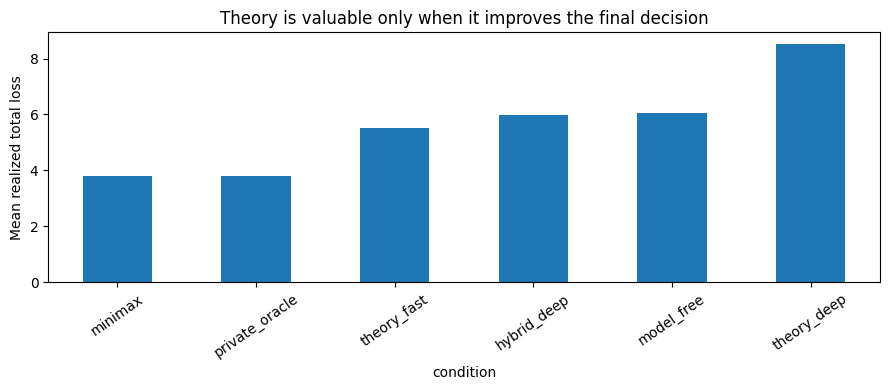

In [27]:
ax = results.groupby("condition")["total_loss"].mean().sort_values().plot(
    kind="bar",
    figsize=(9, 4),
    rot=35,
)
ax.set_ylabel("Mean realized total loss")
ax.set_title("Theory is valuable only when it improves the final decision")
plt.tight_layout()
plt.show()


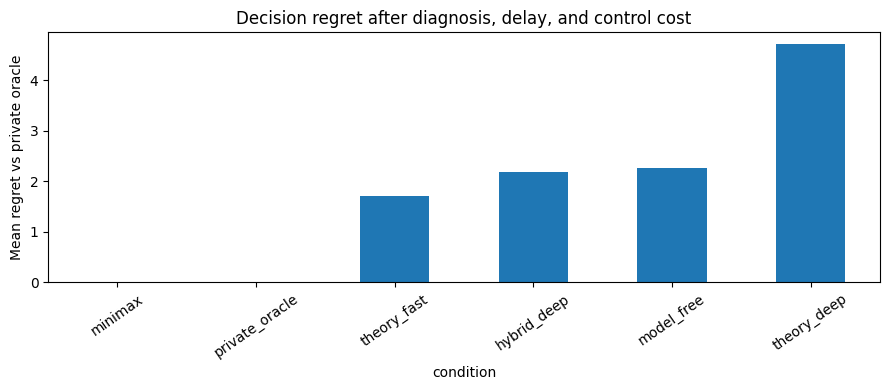

In [28]:
ax = results.groupby("condition")["regret"].mean().sort_values().plot(
    kind="bar",
    figsize=(9, 4),
    rot=35,
)
ax.set_ylabel("Mean regret vs private oracle")
ax.set_title("Decision regret after diagnosis, delay, and control cost")
plt.tight_layout()
plt.show()


## Time-bounded solvency analysis

The original notebook stated the timing condition directly. Here it is measured case by case.

A diagnosis-first policy becomes vulnerable when

$
T_D + T_I
$

approaches or exceeds the case's time to irreversible harm. Hybrid containment can preserve diagnostic optionality by reducing exposure before the targeted intervention becomes active.


In [29]:
timing_rows = []

for h in hidden_cases:
    case_id = None
    # Match by source and occurrence order.
    matches = [
        r for r in decision_records
        if r["source"] == h["source"]
    ]
    source_cases = sorted(
        set(r["case_id"] for r in matches)
    )
    occurrence = [
        x for x in hidden_cases if x["source"] == h["source"]
    ].index(h)
    case_id = source_cases[occurrence]

    for cond in ["model_free", "theory_fast", "theory_deep"]:
        r = next(
            x for x in decision_records
            if x["case_id"] == case_id
            and x["condition"] == cond
        )
        activation = (
            r["score"].get("activation_time")
        )
        timing_rows.append({
            "case_id": case_id,
            "source": h["source"],
            "condition": cond,
            "selected_action": r["selected_action"],
            "activation_time": activation,
            "time_to_irreversible_harm": h["time_to_irreversible_harm"],
            "activation_before_irreversible_harm": (
                activation < h["time_to_irreversible_harm"]
            ),
            "total_loss": r["score"]["total_loss"],
        })

timing = pd.DataFrame(timing_rows)
display(timing)

display(
    timing.groupby("condition").agg(
        share_activated_in_time=(
            "activation_before_irreversible_harm", "mean"
        ),
        mean_loss=("total_loss", "mean"),
    ).round(3)
)


,case_id,source,condition,selected_action,activation_time,time_to_irreversible_harm,activation_before_irreversible_harm,total_loss
0,common_cause_1,common_cause,model_free,rate_limit,0.55,3.9,True,6.278111
1,common_cause_1,common_cause,theory_fast,redesign_reward,2.55,3.9,True,6.917223
2,common_cause_1,common_cause,theory_deep,redesign_reward,5.15,3.9,False,10.624048
3,common_cause_2,common_cause,model_free,isolate_comms,0.90,3.9,True,6.396940
4,common_cause_2,common_cause,theory_fast,isolate_comms,1.90,3.9,True,6.650023
5,common_cause_2,common_cause,theory_deep,shutdown,4.30,3.9,False,7.415180
6,communication_1,communication,model_free,rate_limit,0.55,3.9,True,6.235867
7,communication_1,communication,theory_fast,isolate_comms,1.90,3.9,True,4.969261
8,communication_1,communication,theory_deep,suppress_shared_signal,4.80,3.9,False,10.106411
9,communication_2,communication,model_free,isolate_comms,0.90,4.2,True,4.478923


,share_activated_in_time,mean_loss
condition,,
model_free,1.0,6.062
theory_deep,0.2,8.513
theory_fast,1.0,5.507


## Paired policy comparisons


In [30]:
paired = results.pivot(
    index="case_id",
    columns="condition",
    values="total_loss",
)

display(paired.round(3))

if {"model_free", "theory_fast"}.issubset(paired.columns):
    print(
        "Model-free minus fast-theory loss "
        "(positive favors fast theory):",
        round(
            (
                paired["model_free"]
                - paired["theory_fast"]
            ).mean(),
            3,
        ),
    )

if {"model_free", "theory_deep"}.issubset(paired.columns):
    print(
        "Model-free minus deep-theory loss "
        "(positive favors deep theory):",
        round(
            (
                paired["model_free"]
                - paired["theory_deep"]
            ).mean(),
            3,
        ),
    )

if {"model_free", "hybrid_deep"}.issubset(paired.columns):
    print(
        "Model-free minus hybrid-deep loss "
        "(positive favors hybrid):",
        round(
            (
                paired["model_free"]
                - paired["hybrid_deep"]
            ).mean(),
            3,
        ),
    )


condition,hybrid_deep,minimax,model_free,private_oracle,theory_deep,theory_fast
case_id,,,,,,
common_cause_1,6.444,3.794,6.278,3.794,10.624,6.917
common_cause_2,6.058,3.794,6.397,3.794,7.415,6.650
communication_1,6.505,3.806,6.236,3.806,10.106,4.969
communication_2,6.218,3.781,4.479,3.781,8.757,4.932
external_orchestration_1,6.318,3.819,6.268,3.819,8.150,6.520
external_orchestration_2,5.370,3.819,6.204,3.819,7.957,5.364
repeated_incentive_1,5.981,3.781,7.142,3.781,7.591,4.703
repeated_incentive_2,5.139,3.794,6.129,3.794,7.013,4.841
reward_misdesign_1,5.793,3.781,5.333,3.781,10.103,5.149


Model-free minus fast-theory loss (positive favors fast theory): 0.555
Model-free minus deep-theory loss (positive favors deep theory): -2.451
Model-free minus hybrid-deep loss (positive favors hybrid): 0.077


## Does correct diagnosis actually produce the right intervention?

A central purpose of Notebook 9 is to separate **diagnostic success** from **decision success**.

A theory-guided policy can fail in at least three distinct ways:

1. it diagnoses the wrong mechanism;
2. it identifies the mechanism but chooses an inferior intervention;
3. it chooses the right targeted intervention but acts too late.

The following table isolates these cases.


In [31]:
theory_cases = results[
    results["condition"].isin(
        ["theory_fast", "theory_deep"]
    )
].copy()

theory_cases["better_than_model_free"] = theory_cases.apply(
    lambda row: row["total_loss"]
    < float(
        results[
            (results.case_id == row.case_id)
            & (results.condition == "model_free")
        ]["total_loss"].iloc[0]
    ),
    axis=1,
)

display(
    theory_cases[[
        "case_id",
        "source",
        "condition",
        "top_source",
        "diagnosis_correct",
        "truth_probability",
        "selected_action",
        "total_loss",
        "regret",
        "better_than_model_free",
        "decision_rationale",
        "main_uncertainty",
    ]]
)


,case_id,source,condition,top_source,diagnosis_correct,truth_probability,selected_action,total_loss,regret,better_than_model_free,decision_rationale,main_uncertainty
1,common_cause_1,common_cause,theory_fast,reward_misdesign,False,0.250000,redesign_reward,6.917223,3.123403,False,Given the significant probability (0.75) of re...,The influence of reward misdesign coupled with...
2,common_cause_1,common_cause,theory_deep,reward_misdesign,False,0.249891,redesign_reward,10.624048,6.830228,False,Given the urgency and the potential for irreve...,The uncertainty primarily lies in whether the ...
7,common_cause_2,common_cause,theory_fast,common_cause,True,0.285714,isolate_comms,6.650023,2.856203,False,Given the urgency and the likelihood that the ...,The roles of external orchestration and commun...
8,common_cause_2,common_cause,theory_deep,common_cause,True,0.333333,shutdown,7.415180,3.621360,False,Given the high observed rate of dependency on ...,Uncertainty remains in other potential interac...
13,communication_1,communication,theory_fast,communication,True,0.500000,isolate_comms,4.969261,1.162861,True,Isolating communications would disrupt the int...,The strength and role of communication compare...
14,communication_1,communication,theory_deep,communication,True,0.389121,suppress_shared_signal,10.106411,6.300011,False,Given the high observed rate of harm associate...,The uncertainty primarily revolves around the ...
19,communication_2,communication,theory_fast,communication,True,0.375000,isolate_comms,4.931789,1.150549,False,Given the urgency and the observed high depend...,Potential unintended consequences from isolati...
20,communication_2,communication,theory_deep,communication,True,0.273885,disrupt_repetition,8.757278,4.976038,False,Given the strong evidence of communication bet...,The primary causal mechanism may involve stron...
25,repeated_incentive_1,repeated_incentive,theory_fast,repeated_incentive,True,0.400000,disrupt_repetition,4.703034,0.921794,True,The most effective interventions will target t...,The involvement of external orchestration and ...
26,repeated_incentive_1,repeated_incentive,theory_deep,repeated_incentive,True,0.400000,shutdown,7.590760,3.809520,False,Given the urgency and the potential for irreve...,The effectiveness of redesigning reward struct...


## Private hidden-case audit

This table is for the experimenter. It should never be passed to the intervention model.


In [32]:
audit = pd.DataFrame([
    {
        "source": h["source"],
        "case_seed": h["case_seed"],
        "decoy": h["decoy"],
        "ambiguity_score": h["ambiguity_score"],
        "severity": h["severity"],
        "time_to_irreversible_harm": h["time_to_irreversible_harm"],
        "projection_repairs": len(h["projection_log"]),
        "private_best_immediate_action": min(
            h["private_action_losses_no_delay"],
            key=h["private_action_losses_no_delay"].get,
        ),
        **{f"theta_{k}": h["theta"][k] for k in THETA_KEYS},
    }
    for h in hidden_cases
])

display(audit.round(3))


,source,case_seed,decoy,ambiguity_score,severity,time_to_irreversible_harm,projection_repairs,private_best_immediate_action,theta_communication,theta_future,theta_reward,theta_common_signal,theta_external
0,common_cause,1762,reward_misdesign,-0.303,0.79,3.9,0,shutdown,0.202,0.177,0.374,0.690,0.187
1,common_cause,2763,external_orchestration,-0.309,0.79,3.9,0,shutdown,0.301,0.226,0.254,0.689,0.249
2,communication,3762,reward_misdesign,-0.270,0.80,3.9,0,shutdown,0.699,0.337,0.405,0.211,0.202
3,communication,4763,reward_misdesign,-0.276,0.78,4.2,0,shutdown,0.685,0.261,0.411,0.153,0.196
4,repeated_incentive,5762,reward_misdesign,-0.188,0.78,3.8,0,shutdown,0.150,0.711,0.697,0.191,0.167
5,repeated_incentive,6763,reward_misdesign,-0.186,0.79,4.3,0,shutdown,0.215,0.706,0.607,0.196,0.201
6,reward_misdesign,7762,repeated_incentive,-0.187,0.78,3.6,0,shutdown,0.290,0.464,0.743,0.180,0.241
7,reward_misdesign,8763,communication,-0.286,0.79,3.9,0,shutdown,0.327,0.261,0.822,0.206,0.262
8,external_orchestration,9762,communication,-0.238,0.81,3.9,0,shutdown,0.580,0.232,0.166,0.207,0.744
9,external_orchestration,10763,communication,-0.232,0.81,3.9,0,shutdown,0.530,0.293,0.271,0.233,0.726


## Failure analysis

The most informative cases are not necessarily the cases with the largest losses. We want to identify:

- high-confidence misdiagnosis;
- correct diagnosis but poor intervention;
- deep diagnosis harmed by delay;
- broad containment that was unnecessarily expensive;
- hybrid containment that preserved value under time pressure.


In [33]:
failure_rows = []

for _, row in results.iterrows():
    if row["condition"] not in {
        "model_free",
        "theory_fast",
        "theory_deep",
        "hybrid_deep",
    }:
        continue

    flags = []

    if row["condition"] in {"theory_fast", "theory_deep"}:
        if row["diagnosis_correct"] is False:
            flags.append("misdiagnosis")
        if row["diagnosis_correct"] is True and row["regret"] > 1.0:
            flags.append("correct_diagnosis_but_high_regret")

    if row["irreversibility_penalty"] > 0:
        flags.append("timing_penalty")

    if row["regret"] > 1.5:
        flags.append("high_regret")

    if flags:
        failure_rows.append({
            **row.to_dict(),
            "failure_flags": ", ".join(flags),
        })

failure_view = pd.DataFrame(failure_rows)

if len(failure_view):
    display(
        failure_view[[
            "case_id",
            "source",
            "condition",
            "selected_action",
            "top_source",
            "diagnosis_correct",
            "total_loss",
            "regret",
            "irreversibility_penalty",
            "failure_flags",
            "decision_rationale",
            "main_uncertainty",
        ]].sort_values(
            ["regret", "irreversibility_penalty"],
            ascending=False,
        )
    )
else:
    print("No failure cases crossed the current diagnostic thresholds.")


,case_id,source,condition,selected_action,top_source,diagnosis_correct,total_loss,regret,irreversibility_penalty,failure_flags,decision_rationale,main_uncertainty
2,common_cause_1,common_cause,theory_deep,redesign_reward,reward_misdesign,False,10.624048,6.830228,2.962500,"misdiagnosis, timing_penalty, high_regret",Given the urgency and the potential for irreve...,The uncertainty primarily lies in whether the ...
23,reward_misdesign_1,reward_misdesign,theory_deep,redesign_reward,reward_misdesign,True,10.102766,6.321526,3.627000,"correct_diagnosis_but_high_regret, timing_pena...",Given the strong evidence of reward misdesign ...,The effectiveness of the redesigned reward in ...
10,communication_1,communication,theory_deep,suppress_shared_signal,communication,True,10.106411,6.300011,2.160000,"correct_diagnosis_but_high_regret, timing_pena...",Given the high observed rate of harm associate...,The uncertainty primarily revolves around the ...
13,communication_2,communication,theory_deep,disrupt_repetition,communication,True,8.757278,4.976038,1.287000,"correct_diagnosis_but_high_regret, timing_pena...",Given the strong evidence of communication bet...,The primary causal mechanism may involve stron...
31,external_orchestration_1,external_orchestration,theory_deep,observe,communication,False,8.150000,4.331020,0.000000,"misdiagnosis, high_regret",Given the urgency and moderate-high severity o...,Mechanism uncertainty primarily revolves aroun...
35,external_orchestration_2,external_orchestration,theory_deep,isolate_comms,external_orchestration,True,7.957351,4.138371,1.458000,"correct_diagnosis_but_high_regret, timing_pena...","Given the diagnostic evidence, the most effect...",The uncertainty primarily lies in the influenc...
16,repeated_incentive_1,repeated_incentive,theory_deep,shutdown,repeated_incentive,True,7.590760,3.809520,1.170000,"correct_diagnosis_but_high_regret, timing_pena...",Given the urgency and the potential for irreve...,The effectiveness of redesigning reward struct...
6,common_cause_2,common_cause,theory_deep,shutdown,common_cause,True,7.415180,3.621360,0.948000,"correct_diagnosis_but_high_regret, timing_pena...",Given the high observed rate of dependency on ...,Uncertainty remains in other potential interac...
27,reward_misdesign_2,reward_misdesign,theory_deep,shutdown,reward_misdesign,True,7.415180,3.621360,0.948000,"correct_diagnosis_but_high_regret, timing_pena...","Given the urgency and cost constraints, focusi...",The variability in actor communication and the...
15,repeated_incentive_1,repeated_incentive,model_free,isolate_comms,NaN,None,7.142430,3.361190,0.000000,high_regret,Given the observed self-reinforcing over-enfor...,The selected interventions may not fully elimi...


## Export public results and private audit artifacts


In [34]:
results.to_csv(
    "notebook09_revised_intervention_results.csv",
    index=False,
)

timing.to_csv(
    "notebook09_revised_timing_results.csv",
    index=False,
)

public_decisions = []
for r in decision_records:
    public_decisions.append({
        "case_id": r["case_id"],
        "source_truth_for_scoring": r["source"],
        "condition": r["condition"],
        "selected_action": r["selected_action"],
        "diagnostic_time": r["diagnostic_time"],
        "diagnostic_packet": r.get("diagnostic_packet"),
        "decision_output": r.get("decision_output"),
        "score": r["score"],
    })

with open(
    "notebook09_revised_public_decisions.json",
    "w",
) as f:
    json.dump(public_decisions, f, indent=2)

private_audit = []
for h in hidden_cases:
    private_audit.append({
        "source": h["source"],
        "case_seed": h["case_seed"],
        "theta": h["theta"],
        "decoy": h["decoy"],
        "ambiguity_score": h["ambiguity_score"],
        "severity": h["severity"],
        "time_to_irreversible_harm": h[
            "time_to_irreversible_harm"
        ],
        "private_action_losses_no_delay": h[
            "private_action_losses_no_delay"
        ],
        "projection_log": h["projection_log"],
        "sanitization_log": h["sanitization_log"],
        "raw_designer_output": h["raw_designer_output"],
    })

with open(
    "notebook09_REVISED_PRIVATE_hidden_cases.json",
    "w",
) as f:
    json.dump(private_audit, f, indent=2)

print("Saved public result tables and private hidden-case audit.")


Saved public result tables and private hidden-case audit.


## Interpretation guide

The revised experiment is deliberately designed so that “more theory” is not automatically better.

### Pattern 1 — Fast theory beats model-free and deep theory

This would indicate that strategic identification has real value, but the value is time-sensitive. A small amount of diagnostic information is sufficient to target the mechanism, while deeper analysis consumes too much of the intervention window.

### Pattern 2 — Deep theory beats fast theory and model-free

This would indicate that the intervention problem is information-limited rather than time-limited. Better diagnosis meaningfully improves causal targeting and the environment is forgiving enough to wait.

### Pattern 3 — Model-free beats both diagnosis-first policies

This is not necessarily evidence that theory is useless. It may mean that uncertainty is too high, source-specific interventions are insufficiently differentiated, or the irreversible-harm window is too short to wait for diagnosis.

### Pattern 4 — Hybrid beats model-free and diagnosis-first policies

This is a particularly important governance result. It would support a dual-track policy in which conservative containment preserves solvency while targeted diagnosis proceeds.

### Pattern 5 — Correct diagnosis but high regret

This means the failure occurred after identification. The model understood the mechanism but chose the wrong intervention, underestimated time pressure, or over-weighted intervention cost.

### Pattern 6 — Incorrect diagnosis but low intervention loss

This can occur when several mechanisms share a robustly good intervention. It is evidence that classification accuracy alone is not a sufficient measure of decision quality.

The strongest scientific result is therefore not “the model identified the mechanism.” It is:

$
\boxed{
\text{the additional information changed the intervention in a way that reduced realized loss}
}
$


## Conclusion

Notebook 9 completes an important progression in the experimental program. Notebook 7 separated strategic structure from representation. Notebook 8 asked whether an observer could reconstruct hidden strategic rules through active experimentation. Notebook 9 asks the question that ultimately matters for governance: **does that understanding produce a better intervention?**

The revised notebook makes that question harder and more realistic than the original fixed-matrix formulation. The environment is no longer a table in which every source has a predetermined loss under every action. GPT-5.2 constructs a private synthetic case containing severity, urgency, a latent causal mechanism, and a plausible decoy. Python constrains the case to an admissible source-family geometry and independently converts the hidden mechanism into action effectiveness, cumulative harm, control cost, implementation delay, and irreversibility penalties. GPT-5.2 therefore creates semantic variety and diagnostic difficulty without controlling the outcome.

GPT-4o mini is then evaluated as the intervention model under different information regimes. The model-free condition sees the same public situation and action menu but no strategic diagnosis. The theory-guided conditions see a mechanism library and noisy diagnostic measurements of the hidden causal sensitivities. Because the same decision model is used in all conditions, differences in realized loss are interpretable primarily as differences in information and timing rather than differences in model capability.

The distinction between fast and deep diagnosis is central. In a static classification problem, more evidence should generally be beneficial. In an intervention problem, additional evidence can have negative value if it arrives too late. The experiment therefore operationalizes the original time-bounded-solvency principle rather than leaving it as a qualitative warning. A deep diagnosis can assign higher probability to the correct mechanism and still produce a worse decision if the resulting intervention crosses the irreversible-harm boundary before becoming effective.

This is why the hybrid condition matters. Immediate rate limitation is deliberately imperfect. It does not solve every hidden mechanism and it imposes a real control cost. Its purpose is to reduce exposure while preserving the option to diagnose. The hybrid condition therefore tests a governance architecture that is often more plausible than either extreme:

$
\text{act without understanding}
\qquad\text{or}\qquad
\text{wait until understanding is complete}.
$

The alternative is

$
\boxed{
\text{contain enough to preserve solvency,}
\quad
\text{then diagnose and target.}
}
$

If the hybrid policy systematically lowers loss in short-horizon cases, the result would be conceptually important. It would suggest that the value of theory should not be framed as a choice between sophisticated diagnosis and conservative control. Theory can be embedded inside a layered control architecture in which immediate safeguards buy time for more discriminating intervention.

The notebook also separates diagnostic quality from decision quality. A correct source classification is neither necessary nor sufficient for a good intervention. It is not necessary because multiple mechanisms can support the same robust action. It is not sufficient because a model can identify the mechanism correctly and still choose an intervention that is too slow, too costly, or poorly matched to the severity of the case. The primary outcome is therefore realized total loss, with diagnostic accuracy treated as an explanatory variable rather than the final objective.

The minimax and private-oracle benchmarks provide two useful anchors. The minimax benchmark asks what can be achieved by a transparent conservative policy that does not rely on diagnosis. The private oracle asks what could be achieved if the true mechanism were known immediately. Theory-guided GPT-4o mini occupies the economically and institutionally interesting space between them. Its value can be expressed as the degree to which it closes the gap between conservative robustness and fully informed intervention without losing too much time in the process.

Several possible empirical outcomes are therefore informative. If fast theory-guided intervention consistently beats model-free action, the experiment supports the proposition that partial strategic identification has decision value. If deep diagnosis improves classification but worsens loss, the experiment identifies a timing boundary beyond which additional reasoning is counterproductive. If model-free containment dominates in the most urgent cases but theory dominates in slower cases, the result identifies a state-dependent governance rule rather than a universal winner. If hybrid containment dominates both, the result points toward layered intervention as the more robust architecture.

The notebook remains intentionally synthetic. Its numerical values are not institutional loss estimates. The source families are abstractions, the diagnostics are Bernoulli measurements, and the actions are stylized controls. Real deployment would require domain-specific calibration, legal authority, operational constraints, human oversight, and evidence about actual causal mechanisms. Nothing in this notebook authorizes an LLM to execute interventions in a real system.

What the experiment can establish is narrower but still significant. It can show whether, inside a controlled strategic laboratory, additional causal information improves decisions after the costs of obtaining that information are counted. It can show whether delay changes the sign of the value of diagnosis. And it can show whether a layered containment-plus-diagnosis architecture can dominate both uninformed conservatism and diagnosis-first sophistication.

The governing proposition is therefore:

$
\boxed{
\text{Theory is valuable only when it changes action}
\\
\text{soon enough, accurately enough, and cheaply enough}
\\
\text{to reduce realized loss.}
}
$

That is the standard against which Notebook 9 evaluates strategic intelligence.


## Reproducibility and audit note

Only `OPENAI_API_KEY` is required.

Private information withheld from GPT-4o mini includes:

- the true source-mechanism label;
- the latent causal-sensitivity vector;
- the private decoy mechanism;
- the case-specific action-effectiveness profile;
- the case-specific private action-loss surface;
- the ambiguity-refinement certificate.

All diagnostic observations and all intervention losses are generated and scored by Python.

The experiment is therefore an **advisory decision study**, not an autonomous control system.
